**Loading all libraries**

## Configuration

Before running this notebook, create a `.env` file in the project folder with these four paths:

All data expect the UN dataset which is avaiable on cavas you can download using this <a href='https://drive.google.com/drive/folders/1Ach27hl0Fv4v5MpKTQG63gh2urtSwI1h?usp=sharing' >Click Here</a>

- `data_path`: folder containing the speech text files (the folder which you downloaded from cavnas)
- `speech_path`: Excel file containing speech metadata (Speakers_by_session.xlsx)
- `conflicts_path`: UCDP conflicts CSV file (conflicts.csv)
- `sipri_path`: SIPRI military expenditure Excel file (spiri.xlsx)

The paths are loaded automatically below. Users only need to update their own `.env` file.


In [ ]:
from dotenv import load_dotenv
import os
import pandas as pd
import re  # for the patterns
import nltk
from nltk.corpus import stopwords

load_dotenv(override=True)

DATA_PATH = os.getenv("data_path")
SPEECH_PATH = os.getenv("speech_path") or os.getenv("speach_path")
CONFLICTS_PATH = os.getenv("conflicts_path")
SIPRI_PATH = os.getenv("sipri_path")

required_paths = {
    "data_path": DATA_PATH,
    "speech_path": SPEECH_PATH,
    "conflicts_path": CONFLICTS_PATH,
    "sipri_path": SIPRI_PATH,
}
missing_paths = [name for name, value in required_paths.items() if not value]
if missing_paths:
    raise ValueError(
        f"Missing environment variables: {', '.join(missing_paths)}"
    )

In [84]:
excel = pd.read_excel(SPEECH_PATH)
print(excel.columns)
# lets drop unnecessary column
speach_df = excel.drop(columns=["Unnamed: 6"])

Index(['Year', 'Session', 'ISO Code', 'Country', 'Name of Person Speaking',
       'Post', 'Unnamed: 6'],
      dtype='str')


# New its time to add speach to each session and person

In [85]:
# Make the Excel values use the same types as the values in the filenames.
speach_df["ISO Code"] = speach_df["ISO Code"].astype(str).str.strip()
speach_df["Session"] = pd.to_numeric(speach_df["Session"])
speach_df["Year"] = pd.to_numeric(speach_df["Year"])

if "Speech" not in speach_df.columns:
    speach_df["Speech"] = pd.NA

number_of_sessions = 0
files_processed = 0
files_matched = 0
files_unmatched = 0
files_skipped = 0
skipped_files = []
unmatched_files = []

for folder_name in os.listdir(DATA_PATH):
    folder_path = os.path.join(DATA_PATH, folder_name)
    if not os.path.isdir(folder_path):
        continue

    for session_name in os.listdir(folder_path):
        session_path = os.path.join(folder_path, session_name)
        if not os.path.isdir(session_path):
            continue

        number_of_sessions += 1

        for txt_file in os.listdir(session_path):
            if not txt_file.endswith(".txt"):
                continue

            parts = txt_file[:-4].split("_")
            if len(parts) != 3:
                files_skipped += 1
                skipped_files.append(txt_file)
                continue

            iso_code, session_num, year = parts
            try:
                session_num = int(session_num)
                year = int(year)
            except ValueError:
                files_skipped += 1
                skipped_files.append(txt_file)
                continue

            try:
                with open(os.path.join(session_path, txt_file), "r", encoding="utf-8") as file:
                    speech_text = file.read()
            except (OSError, UnicodeDecodeError):
                files_skipped += 1
                skipped_files.append(txt_file)
                continue

            files_processed += 1
            mask = (
                (speach_df["ISO Code"] == iso_code.strip())
                & (speach_df["Session"] == session_num)
                & (speach_df["Year"] == year)
            )

            if not mask.any():
                files_unmatched += 1
                unmatched_files.append(txt_file)
                continue

            # Update every row when the metadata contains duplicate keys.
            speach_df.loc[mask, "Speech"] = speech_text
            files_matched += 1

missing_speeches = speach_df["Speech"].isna().sum()
print(f"Sessions found: {number_of_sessions}")
print(f"Speech files processed: {files_processed}")
print(f"Speech files matched: {files_matched}")
print(f"Speech files without a metadata match: {files_unmatched}")
print(f"Files skipped: {files_skipped}")
print(f"Metadata rows without speech: {missing_speeches}")

print("\nSkipped file names:")
print(skipped_files if skipped_files else "None")

print("\nFiles without a metadata match:")
print(unmatched_files if unmatched_files else "None")

Sessions found: 80
Speech files processed: 11141
Speech files matched: 11063
Speech files without a metadata match: 78
Files skipped: 1
Metadata rows without speech: 54

Skipped file names:
['.DS_Store-to-UTF-8.txt']

Files without a metadata match:
['YMD_29_1974.txt', 'YMD_27_1972.txt', 'YMD_34_1979.txt', 'YMD_38_1983.txt', 'IRQ_18_1963.txt', 'SOM_18_1963.txt', 'JAM_18_1963.txt', 'GAB_18_1963.txt', 'UKR_18_1963.txt', 'ZAF_18_1963.txt', 'SDN_18_1963.txt', 'HTI_18_1963.txt', 'SAU_18_1963.txt', 'CUB_18_1963.txt', 'EGY_18_1963.txt', 'SLE_18_1963.txt', 'TZA_18_1963.txt', 'PHL_18_1963.txt', 'POL_18_1963.txt', 'CHN_18_1963.txt', 'ECU_18_1963.txt', 'BFA_18_1963.txt', 'MYS_18_1963.txt', 'CAF_18_1963.txt', 'CYP_18_1963.txt', 'MEX_18_1963.txt', 'SYR_18_1963.txt', 'IND_18_1963.txt', 'MDG_18_1963.txt', 'NOR_18_1963.txt', 'MLI_18_1963.txt', 'DOM_18_1963.txt', 'ETH_18_1963.txt', 'RWA_18_1963.txt', 'BEL_18_1963.txt', 'COD_18_1963.txt', 'CSK_02_1947.txt', 'YMD_35_1980.txt', 'YMD_44_1989.txt', 'YMD_23_

# the number of metadata without speeach is rather small so just drop them

In [86]:
speach_df = speach_df.dropna(subset=["Speech"])

# Instead of nulls in 'Post' column let's add just 'Unknown'

In [87]:
speach_df["Post"] = speach_df["Post"].fillna("Unknown")
speach_df["Country"] = speach_df["Country"].str.strip()

# Fix one corrupted cell (broken Excel formula leaked into 'Country')

In [88]:
speach_df.loc[speach_df["Country"] == "29+C70+A7+D71:E74", "Country"] = "Ethiopia"

## Dataset II - UCDP Conflict Data

Load the UCDP/PRIO conflict dataset.

In [89]:
conflicts_df = pd.read_csv(CONFLICTS_PATH)

## Dataset III - SIPRI Military Spending

Load SIPRI's "Share of GDP" sheet, skipping header/region rows.

In [90]:
def load_sipri_sheet(path, sheet_name, header_row, year_start_col):
    df = pd.read_excel(
        path,
        sheet_name=sheet_name,
        header=header_row,              # row 6 (0-indexed: 5)
        na_values=["..", "xxx", "..."]  # treat these as missing
    )

    # Identify the year columns (everything from year_start_col onward).
    # Doing this BEFORE dropping 'Notes' keeps the column positions predictable.
    year_cols = df.columns[year_start_col:]

    # Drop rows that are region headers (e.g. "Africa", "Asia") or blank spacer rows.
    # These rows always have every year column empty, even though 'Country' itself
    # is populated (so a plain df.dropna(how="all") would NOT catch them, since
    # 'Country' being non-empty makes the row look "not all empty").
    # subset=year_cols restricts the emptiness check to just the year columns,
    # ignoring 'Country'/'Notes' entirely.
    df = df.dropna(subset=year_cols, how="all")

    df = df.drop(columns="Notes")
    return df


# year_start_col=2 because the raw columns are: [Country, Notes, 1949, 1950, ...]
#   index 0 = Country, index 1 = Notes, index 2 = first year (1949)
gdp_share = load_sipri_sheet(SIPRI_PATH, "Share of GDP", header_row=5, year_start_col=2)
gdp_share


,Country,1949,1950,1951,1952,1953,1954,1955,1956,1957,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
3,Algeria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.056527,0.053071,0.049299,0.053270,0.058861,0.048900,0.040575,0.073904,0.079715,0.088306
4,Libya,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.028038,0.035725,NaN,NaN
5,Morocco,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011807,0.01759,...,0.029821,0.029459,0.029029,0.028658,0.039797,0.037498,0.038049,0.035528,0.034351,0.035431
6,Tunisia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.022250,0.020318,0.019764,0.023833,0.027128,0.026151,0.025512,0.025049,0.024989,0.024950
8,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.027333,0.025080,0.019558,0.017679,0.018104,0.013932,0.014327,0.014298,0.010339,0.013968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,Saudi Arabia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.092376,0.094973,0.084159,0.073533,0.084066,0.064310,0.057236,0.063816,0.064052,0.064823
188,Syria,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
189,Türkiye,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.020477,0.020385,0.024921,0.026384,0.021558,0.018145,0.016248,0.016853,0.018403,0.019083
190,United Arab Emirates,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Now, let's melt the table

# Why we melt `gdp_share` into long format

Right now `gdp_share` is **wide**: one row per country, one column per year (1949–2025).
That's fine for a human reading a spreadsheet, but it can't be merged with our other
two datasets, because:

- **Speeches** are one row per `(country, year)`
- **UCDP conflict data** is one row per `(country, year)`

To join SIPRI onto these, it needs to have the same shape: **one row per `(country, year)`**,
not one row per country with 77 year-columns.

**Melting** = unpivoting. It turns each year-column into its own row.

| Before (wide) |      |      |      |
|---|---|---|---|
| Country | 1949 | 1950 | 1951 |
| Algeria | NaN  | NaN  | 2.1  |

| After (long) |      |      |
|---|---|---|
| Country | Year | milex_pct_gdp |
| Algeria | 1949 | NaN |
| Algeria | 1950 | NaN |
| Algeria | 1951 | 2.1 |

Once every row is a single `(country, year, value)`, we can merge it directly onto
the speeches and conflict data using `(Country, Year)` as the shared key.

In [91]:
gdp_long = gdp_share.melt(
    id_vars=["Country"],
    var_name="Year",
    value_name="milex_pct_gdp"
)

gdp_long["Year"] = gdp_long["Year"].astype(int)
gdp_long = gdp_long.dropna(subset=["milex_pct_gdp"])
gdp_df = gdp_long

# Standardize historical/alias country names

Speeches, UCDP, and SIPRI each use different spellings for the same countries
(whitespace, typos, formal names, and old names). We standardize speech names to
match SIPRI's style using a hand-built rename dictionary, built by comparing the
three datasets' unique country lists.

In [92]:
# True 1-to-1 renames: same country/entity, just an old name -> current SIPRI-style name
rename_dict = {
    "Burma": "Myanmar",
    "Union of Burma": "Myanmar",
    "Union of Myanmar": "Myanmar",
    "Myanmar / Burma": "Myanmar",
    "Ceylon": "Sri Lanka",
    "Ceylon (Sri Lanka)": "Sri Lanka",
    "Zaire": "Congo, DR",
    "Congo, Leopoldville": "Congo, DR",
    "Congo, the Democratic Republic of the/Zaire": "Congo, DR",
    "Democratic Republic of Congo": "Congo, DR",
    "Democratic Republic Of Congo": "Congo, DR",
    "Democratic Republic of the Congo": "Congo, DR",
    "DRC": "Congo, DR",
    "Congo, Brazzaville": "Congo, Republic",
    "Congo (Brazzaville": "Congo, Republic",
    "Congo, the Peoples Republic of the": "Congo, Republic",
    "Dahomey": "Benin",
    "Benin (Dahomey)": "Benin",
    "Upper Volta": "Burkina Faso",
    "Upper Volta/Burkina Faso": "Burkina Faso",
    "Siam": "Thailand",
    "Swaziland": "Eswatini",
    "Kingdom of Eswatini": "Eswatini",
    "Macedonia": "North Macedonia",
    "Macedonia, the former Yugoslav Republic of": "North Macedonia",
    "Republic of North Macedonia": "North Macedonia",
    "Kampuchea": "Cambodia",
    "Democratic Kampuchea": "Cambodia",
    "Khmer Republic": "Cambodia",
    "Cambodia /Kampuchea": "Cambodia",
    "Western Samoa": "Samoa",
    "Independent State of Samoa": "Samoa",
    "Samoa": "Samoa",
    "Timor-Leste": "Timor Leste",
    "Democratic Republic of Timor-Leste": "Timor Leste",
    "Czech Republic": "Czechia",
    "Turkey": "Türkiye",
    "Republic of Turkey": "Türkiye",
}

Apply the rename dictionary to speech country names.

In [93]:
speach_df["Country"] = speach_df["Country"].replace(rename_dict)
print(len(speach_df["Country"].unique()))

514


# Flag historical states that split/merged/dissolved (no valid modern equivalent)

USSR, Czechoslovakia, Yugoslavia, divided Germany, and Yemen before 1990 no
longer exist as single modern entities. Mapping them to one successor state
would be factually wrong, so we flag these rows rather than dropping or
force-mapping them. They remain usable for text analysis but are excluded from
models requiring SIPRI/UCDP country-year variables.

In [94]:
impossible_bucket = [
    # USSR variants
    "USSR", "USSR ", "Union of Socialist Soviet Republics",
    "Union of Sovier Socialist Republics", "Union of Soviet Socialist Republics",
    "Russian Federation (USSR)",

    # Czechoslovakia
    "Czechoslovakia", "Czechoslovak Socialist Republic",

    # Yugoslavia
    "Yugoslavia", "Serbia and Montenegro",

    # Germany (pre-unification, both sides)
    "German Democratic Republic", "Germany Democratic Republic",
    "Democratic Republic of Germany", "GDR", "DDR", "FDR", "FDR (Germany)",
    "Federal Republic Germany", "Federal Republic of Germany",
    "Republica Federal Alemana",

    # Yemen (pre-1990 unification, both sides)
    "Yemen Arab Republic",

    # Byelorussian/Ukrainian SSR (distinct UN seats pre-1991, now part of modern Belarus/Ukraine
    # via full independence, not a simple rename - USSR breakup case)
    "BSSR", "BelSSR", "Byelorussian Soviet Socialist Republic",
    "Byelorussian Soviet Socialist Repulic",
    "Belarus, Byelorussian Soviet Socialist Republic",
    "UkrSSR", "Ukraine SSR", "Ukrainian Soviet Socialist Republic",
    "Ukranian SSR", "Ukranian Soviet Socialist Republic",
]
# Flag these rows explicitly instead of dropping them
speach_df["historical_entity_unmatched"] = speach_df["Country"].isin(impossible_bucket)

print(f"Rows flagged as historical/unmatched: {speach_df['historical_entity_unmatched'].sum()}")
print(f"Out of total rows: {len(speach_df)}")

# Which years do these cluster in? (sanity check - should be Cold War era + early 90s)
print(speach_df[speach_df["historical_entity_unmatched"]]["Year"].value_counts().sort_index())

Rows flagged as historical/unmatched: 250
Out of total rows: 11080
Year
1946    5
1947    4
1948    5
1949    5
1950    5
1951    6
1952    5
1953    5
1954    5
1955    5
1956    5
1957    6
1958    7
1959    6
1960    5
1961    5
1962    5
1963    4
1964    5
1965    5
1966    5
1967    5
1968    5
1969    5
1970    1
1971    4
1972    5
1973    5
1974    7
1975    5
1976    8
1977    5
1978    7
1979    5
1980    6
1981    5
1982    6
1983    4
1984    6
1985    8
1986    6
1987    5
1988    7
1989    6
1990    6
1991    2
1992    1
2001    1
2002    1
2003    1
2004    1
2005    1
2019    1
2020    1
Name: count, dtype: int64


"Federal Republic of Germany" means different things before/after 1990 - fix that ambiguity.

In [95]:
# "Federal Republic of Germany" is ambiguous: pre-1990 it is historical West Germany;
# post-1990 it is modern Germany's official long-form name.
mask_germany_post1990 = (
    (speach_df["Country"] == "Federal Republic of Germany")
    & (speach_df["Year"] >= 1990)
)
speach_df.loc[mask_germany_post1990, "Country"] = "Germany"
speach_df.loc[mask_germany_post1990, "historical_entity_unmatched"] = False

Result: 250 of 11,080 speeches (2.3%) flagged as historical/unmatched, concentrated in 1946-1992. Kept for text analysis, excluded from SIPRI/UCDP merges.

Split UCDP's multi-country "location" field into one row per country.

In [96]:
# Split multi-country location entries into separate rows.
conflicts_df = conflicts_df.assign(
    Country=conflicts_df["location"].str.split(", ")
).explode("Country")

conflicts_df["Country"] = conflicts_df["Country"].str.strip()

Apply the same rename + historical-entity flagging used for speeches, adapted to UCDP's naming style.

In [97]:
# UCDP-specific renames: same entities as before, but UCDP phrases them differently.
ucdp_rename_dict = {
    "Cambodia (Kampuchea)": "Cambodia",
    "Myanmar (Burma)": "Myanmar",
    "Madagascar (Malagasy)": "Madagascar",
    "DR Congo (Zaire)": "Congo, DR",
    "Congo": "Congo, Republic",
}

rename_dict.update(ucdp_rename_dict)

ucdp_impossible_bucket = [
    "Russia (Soviet Union)",
    "South Yemen",
    "Yemen (North Yemen)",
    "Serbia (Yugoslavia)",
    "South Vietnam",
    "Vietnam (North Vietnam)",
    "Zimbabwe (Rhodesia)",
]

impossible_bucket.extend(ucdp_impossible_bucket)

conflicts_df["Country"] = conflicts_df["Country"].replace(rename_dict)
conflicts_df["historical_entity_unmatched"] = conflicts_df["Country"].isin(impossible_bucket)

Some UCDP labels stay fixed for a conflict's whole record even after the country's status changed - correct those post-transition rows.

In [98]:
# Russia (Soviet Union): USSR dissolved in 1991. Post-1991 rows are modern Russia.
mask_russia_post1991 = (
    (conflicts_df["Country"] == "Russia (Soviet Union)")
    & (conflicts_df["year"] >= 1992)
)
conflicts_df.loc[mask_russia_post1991, "Country"] = "Russia"
conflicts_df.loc[mask_russia_post1991, "historical_entity_unmatched"] = False

# Vietnam (North Vietnam): unified with South Vietnam in 1976. Post-1976 rows are unified Vietnam.
mask_vietnam_post1976 = (
    (conflicts_df["Country"] == "Vietnam (North Vietnam)")
    & (conflicts_df["year"] >= 1976)
)
conflicts_df.loc[mask_vietnam_post1976, "Country"] = "Viet Nam"
conflicts_df.loc[mask_vietnam_post1976, "historical_entity_unmatched"] = False

# Yemen (North Yemen): unified with South Yemen in 1990. Post-1990 rows are unified Yemen.
mask_yemen_post1990 = (
    (conflicts_df["Country"] == "Yemen (North Yemen)")
    & (conflicts_df["year"] >= 1990)
)
conflicts_df.loc[mask_yemen_post1990, "Country"] = "Yemen"
conflicts_df.loc[mask_yemen_post1990, "historical_entity_unmatched"] = False

Final naming fixes to match SIPRI, plus flagging Hyderabad (not a modern country).

In [99]:
# Final UCDP -> SIPRI naming fixes, plus Hyderabad (a 1948-absorbed princely state,
# not a country in any modern dataset - flagged rather than mapped anywhere).
final_rename_dict = {
    "Bosnia-Herzegovina": "Bosnia and Herzegovina",
    "Gambia": "Gambia, The",
    "Ivory Coast": "Cote d'Ivoire",
    "Kyrgyzstan": "Kyrgyz Republic",
    "South Korea": "Korea, South",
}
rename_dict.update(final_rename_dict)
conflicts_df["Country"] = conflicts_df["Country"].replace(final_rename_dict)

impossible_bucket.append("Hyderabad")
conflicts_df["historical_entity_unmatched"] = conflicts_df["Country"].isin(impossible_bucket)

UCDP cleanup done: 98 of 2,990 rows flagged as historical (time-accurate). North Korea, Comoros, Grenada, and Suriname have no SIPRI military-spending data - a genuine gap, not a naming issue.

In [100]:
# Aggregate conflicts_df to one row per (Country, Year).
# A country can have multiple simultaneous conflicts in the same year, so we
# collapse those into a few summary columns rather than keeping multiple rows.

conflicts_agg = (
    conflicts_df[~conflicts_df["historical_entity_unmatched"]]  # drop historical/unmatched entities first
    .groupby(["Country", "year"])
    .agg(
        conflict_active=("conflict_id", "count"),       # will convert to 1/0 below
        max_intensity=("intensity_level", "max"),        # 1=Minor, 2=War
        n_conflicts=("conflict_id", "nunique"),           # number of distinct conflicts that year
        any_war=("intensity_level", lambda x: (x == 2).any())  # True if any conflict reached War level
    )
    .reset_index()
)

# conflict_active should be a 1/0 flag, not a raw count
conflicts_agg["conflict_active"] = (conflicts_agg["conflict_active"] > 0).astype(int)
conflicts_agg["any_war"] = conflicts_agg["any_war"].astype(int)

conflicts_agg = conflicts_agg.rename(columns={"year": "Year"})

print(f"Rows before aggregation: {len(conflicts_df)}")
print(f"Rows after aggregation (unique Country-Year pairs): {len(conflicts_agg)}")
conflicts_agg.head(10)

Rows before aggregation: 2990
Rows after aggregation (unique Country-Year pairs): 2024


,Country,Year,conflict_active,max_intensity,n_conflicts,any_war
0,Afghanistan,1978,1,2,1,1
1,Afghanistan,1979,1,2,2,1
2,Afghanistan,1980,1,2,1,1
3,Afghanistan,1981,1,2,1,1
4,Afghanistan,1982,1,2,1,1
5,Afghanistan,1983,1,2,1,1
6,Afghanistan,1984,1,2,1,1
7,Afghanistan,1985,1,2,1,1
8,Afghanistan,1986,1,2,1,1
9,Afghanistan,1987,1,2,1,1


# Time to merge all 3 datasets

In [101]:
"""
Merge speeches (base table) with UCDP conflict data and SIPRI military spending,
then apply the study's locked scope (1990-2025, historical entities excluded).

NaN handling differs by source, since a missing match means something different
for each:
- Conflict columns: NaN after the join means the country-year was not in
  conflicts_agg, i.e. no conflict occurred. These become 0.
- milex_pct_gdp: NaN means SIPRI has no reported data for that country-year
  (a genuine coverage gap). Left as NaN, not filled with 0, since 0 would
  falsely imply zero military spending.

Rows for historical/dissolved entities (USSR, Yugoslavia, etc.) are dropped
here, since they cannot be validly linked to modern SIPRI/UCDP country codes.
They remain valid for text-only analysis elsewhere.
"""

# Speeches is the base table - every other dataset is left-joined onto it
merged = speach_df.merge(conflicts_agg, on=["Country", "Year"], how="left")
merged = merged.merge(gdp_df, on=["Country", "Year"], how="left")

# Missing conflict data means no conflict happened -> fill with 0
conflict_cols = ["conflict_active", "max_intensity", "n_conflicts", "any_war"]
merged[conflict_cols] = merged[conflict_cols].fillna(0).astype(int)

# Apply locked scope: 1990-2025, drop historical/unmatched entities
merged = merged[
    (merged["Year"] >= 1990)
    & (merged["Year"] <= 2025)
    & (~merged["historical_entity_unmatched"])
].reset_index(drop=True)

print(f"Final merged dataset: {len(merged)} rows")
print(f"Conflict-active rate: {merged['conflict_active'].mean():.1%}")
print(f"SIPRI coverage (non-null milex_pct_gdp): {merged['milex_pct_gdp'].notna().mean():.1%}")

Final merged dataset: 6680 rows
Conflict-active rate: 14.9%
SIPRI coverage (non-null milex_pct_gdp): 70.1%


# Basic text pre-processing for the EDA

In [102]:
import re

def basic_clean(text):
    """
    Light cleaning for EDA purposes only (not the final modeling pipeline).
    Lowercases, strips extra whitespace/line breaks, removes punctuation,
    and tokenizes into words. Keeps things simple and fast - deeper
    cleaning (lemmatization, custom stopword lists, etc.) comes later
    once we know what the modeling pipeline actually needs.
    """
    text = str(text).lower()

    # Collapse newlines/tabs/multiple spaces into single spaces
    text = re.sub(r"\s+", " ", text)

    # Remove punctuation/numbers, keep only letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    return text.strip()


merged["speech_clean"] = merged["Speech"].apply(basic_clean)

# Tokenize into words
merged["tokens"] = merged["speech_clean"].str.split()

print(merged[["Country", "Year", "speech_clean"]].head(2))
print()
print("Example tokens:", merged["tokens"].iloc[0][:15])


   Country  Year                                       speech_clean
0   Angola  2025  the assembly will hear an address by his excel...
1  Albania  2025  excellency  the assembly will now hear an addr...

Example tokens: ['the', 'assembly', 'will', 'hear', 'an', 'address', 'by', 'his', 'excellency', 'zuan', 'manuel', 'gonz', 'lez', 'louren', 'o']


In [103]:
# for macOS users, to avoid SSL certificate verification issues when downloading NLTK data
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [104]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 2]

merged["tokens_clean"] = merged["tokens"].apply(remove_stopwords)

print("Before:", merged["tokens"].iloc[0][:15])
print("After: ", merged["tokens_clean"].iloc[0][:15])

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jakubkucz/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Before: ['the', 'assembly', 'will', 'hear', 'an', 'address', 'by', 'his', 'excellency', 'zuan', 'manuel', 'gonz', 'lez', 'louren', 'o']
After:  ['assembly', 'hear', 'address', 'excellency', 'zuan', 'manuel', 'gonz', 'lez', 'louren', 'president', 'republic', 'angola', 'request', 'protocol', 'escort']


**Exploratory Data Analysis**

Research question: *Do trust/cooperation rhetoric, military-threat rhetoric, and military spending in a given year differ depending on whether a country experiences conflict the following year?* We test each of the three signals separately, using the year before conflict onset as the comparison point.

Early testing used random placeholder values to validate the pipeline structure before running the real (slow) classification below. Left here, commented out, for transparency.

In [105]:
# import numpy as np

# # Temporary placeholder values - one independent random number PER ROW,
# # not a single number broadcast to the whole column. Replace with real
# # classify_rhetoric() output later.
# merged["trust_score"] = np.random.rand(len(merged))
# merged["threat_score"] = np.random.rand(len(merged))

**Measuring rhetoric with zero-shot classification.** Rather than counting exact keywords (which we tested separately and found showed no meaningful pattern — see Methodology), we use a zero-shot classification model to score each speech's semantic similarity to two themes: trust/cooperation and military threat. This detects meaning even when a speech never uses the literal words "trust" or "threat." We use `ModernBERT-large-zeroshot-v2.0` specifically because it handles long text without truncation — important here since speeches range from ~300 to 8,000+ words across the corpus.

In [106]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="MoritzLaurer/ModernBERT-large-zeroshot-v2.0",
    device="mps"
)
candidate_labels = [
    "trust and international cooperation",
    "military threat and security concerns",
]

def classify_rhetoric(speech_text):
    result = classifier(speech_text, candidate_labels, multi_label=True)
    scores = dict(zip(result["labels"], result["scores"]))
    return pd.Series({
        "trust_score": scores["trust and international cooperation"],
        "threat_score": scores["military threat and security concerns"],
    })


rhetoric_scores = merged["Speech"].apply(classify_rhetoric)
merged = pd.concat([merged, rhetoric_scores], axis=1)

Loading weights: 100%|██████████| 174/174 [00:00<00:00, 6049.43it/s]


**Building the forecasting structure.** To test whether this year's signals relate to *next* year's conflict, we shift each country's conflict status back by one year within its own timeline. The most recent year (2025) has no "following year" available and is automatically excluded from this comparison.

In [107]:
# 1. Ensure your data is sorted by Country and Year
merged = merged.sort_values(['Country', 'Year'])

# 2. Create the next year's target using shift(-1) within each country group
merged['conflict_active_next_year'] = merged.groupby('Country')['conflict_active'].shift(-1)


Comparing mean values of trust score, threat score, and military spending, grouped by whether the country experiences conflict the following year.

In [108]:
variables = ["trust_score", "threat_score", "milex_pct_gdp"]

group_summary = merged.groupby("conflict_active_next_year")[variables].agg(["mean", "std", "count"])
print(group_summary)

                          trust_score                 threat_score            \
                                 mean       std count         mean       std   
conflict_active_next_year                                                      
0.0                          0.223075  0.306999  5302     0.026744  0.113615   
1.0                          0.188804  0.291431   953     0.038080  0.142083   

                                milex_pct_gdp                  
                          count          mean       std count  
conflict_active_next_year                                      
0.0                        5302      0.019630  0.027478  3671  
1.0                         953      0.030142  0.035325   865  


**Testing whether the differences are real.** A t-test tells us whether the difference in average scores between the two groups (conflict-next-year vs. not) is likely to be a genuine pattern or just random variation. We treat p < 0.05 as the threshold for statistical significance — below this, the observed difference is unlikely to have occurred by chance alone.

In [109]:
from scipy import stats

def run_ttest(df, variable, group_col):
    group0 = df[df[group_col] == 0][variable].dropna()
    group1 = df[df[group_col] == 1][variable].dropna()
    t_stat, p_value = stats.ttest_ind(group0, group1)
    return t_stat, p_value

for var in variables:
    t_stat, p_value = run_ttest(merged, var, "conflict_active_next_year")
    print(f"{var}: t = {t_stat:.3f}, p = {p_value:.4f}")

trust_score: t = 3.197, p = 0.0014
threat_score: t = -2.721, p = 0.0065
milex_pct_gdp: t = -9.546, p = 0.0000


Visualizing the distributions directly makes the group differences easier to interpret than summary statistics alone.

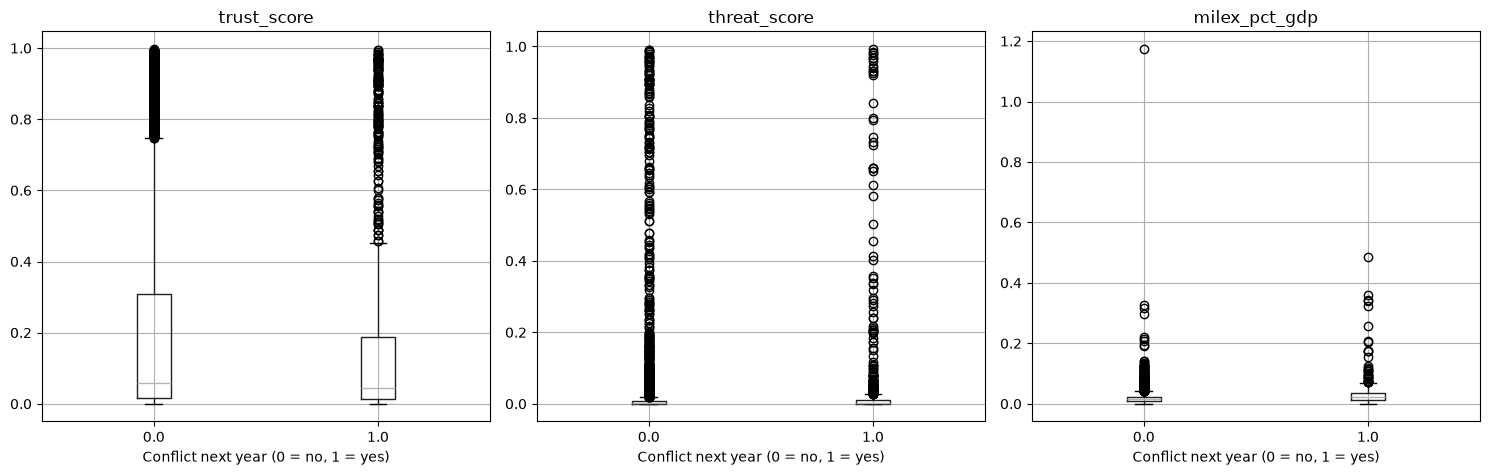

In [110]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, var in zip(axes, variables):
    merged.boxplot(column=var, by="conflict_active_next_year", ax=ax)
    ax.set_title(var)
    ax.set_xlabel("Conflict next year (0 = no, 1 = yes)")

plt.suptitle("")  # removes the default pandas suptitle
plt.tight_layout()
plt.show()

**Ruling out a confound.** Speech length varies enormously across the corpus (older speeches are much longer). Before trusting the rhetoric scores, we check whether length itself is driving them — if longer speeches always scored higher on trust or threat regardless of content, that would undermine the result. The correlations here are close to zero, so length is not a meaningful confound.

               speech_length  trust_score  threat_score
speech_length       1.000000     0.010517     -0.017800
trust_score         0.010517     1.000000     -0.091499
threat_score       -0.017800    -0.091499      1.000000


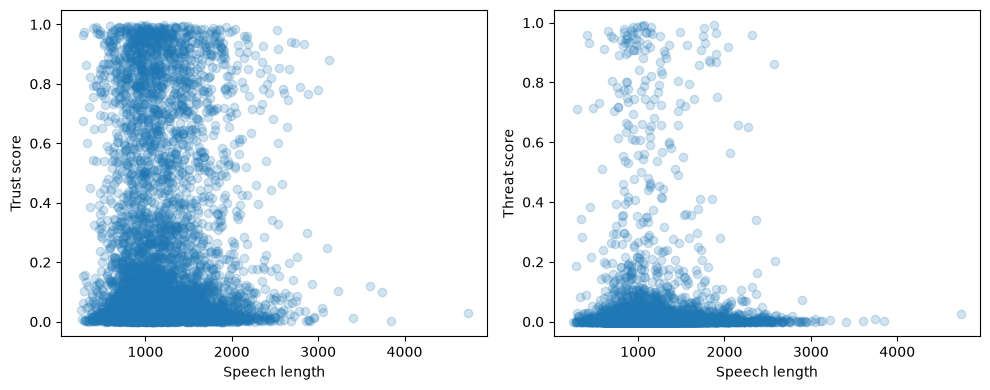

In [111]:
merged["speech_length"] = merged["tokens_clean"].apply(len)

correlation = merged[["speech_length", "trust_score", "threat_score"]].corr()
print(correlation)

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(merged["speech_length"], merged["trust_score"], alpha=0.2)
axes[0].set_xlabel("Speech length")
axes[0].set_ylabel("Trust score")

axes[1].scatter(merged["speech_length"], merged["threat_score"], alpha=0.2)
axes[1].set_xlabel("Speech length")
axes[1].set_ylabel("Threat score")

plt.tight_layout()
plt.show()

Saving the fully processed dataset so it doesn't need to be rebuilt (including the ~1 hour classification step) in future sessions.

In [112]:
merged.to_csv("merged_data.csv", index=False)

**Measuring how large the difference actually is.** A t-test only tells us *whether* a difference is statistically real — with a large sample like ours (n ≈ 6,255), even a very small difference can be statistically significant. Cohen's d measures the *size* of the effect independent of sample size, letting us judge whether a significant result is also practically meaningful. As a rule of thumb: ~0.2 = small, ~0.5 = medium, ~0.8 = large.

In [113]:
def cohens_d(df, variable, group_col):
    group0 = df[df[group_col] == 0][variable].dropna()
    group1 = df[df[group_col] == 1][variable].dropna()
    n0, n1 = len(group0), len(group1)
    pooled_std = (((n0 - 1) * group0.std()**2 + (n1 - 1) * group1.std()**2) / (n0 + n1 - 2)) ** 0.5
    return (group1.mean() - group0.mean()) / pooled_std

for var in variables:
    d = cohens_d(merged, var, "conflict_active_next_year")
    print(f"{var}: Cohen's d = {d:.3f}")

trust_score: Cohen's d = -0.112
threat_score: Cohen's d = 0.096
milex_pct_gdp: Cohen's d = 0.361


Comparing effect sizes directly shows that military spending is a substantially stronger signal than either rhetoric measure, even though all three are statistically significant.

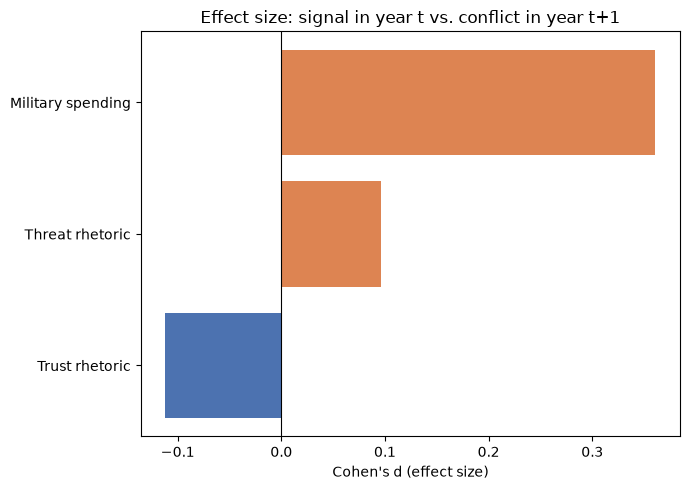

In [114]:
import matplotlib.pyplot as plt

effect_sizes = {"Trust rhetoric": -0.112, "Threat rhetoric": 0.096, "Military spending": 0.361}

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#4C72B0" if v < 0 else "#DD8452" for v in effect_sizes.values()]
ax.barh(list(effect_sizes.keys()), list(effect_sizes.values()), color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Cohen's d (effect size)")
ax.set_title("Effect size: signal in year t vs. conflict in year t+1")
plt.tight_layout()
plt.show()

Tracking how the balance between trust/cooperation and military-threat rhetoric has shifted across the full 1990–2025 window.

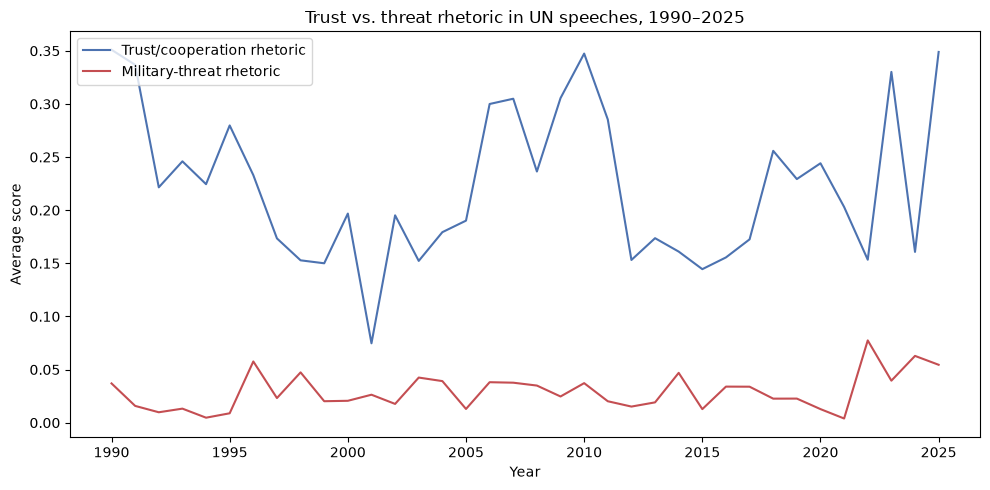

In [121]:
trend = merged.groupby("Year")[["trust_score", "threat_score"]].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trend.index, trend["trust_score"], label="Trust/cooperation rhetoric", color="#4C72B0")
ax.plot(trend.index, trend["threat_score"], label="Military-threat rhetoric", color="#C44E52")
ax.set_xlabel("Year")
ax.set_ylabel("Average score")
ax.legend(loc="upper left")
ax.set_title("Trust vs. threat rhetoric in UN speeches, 1990–2025")
plt.tight_layout()
plt.show()

Comparing military spending trajectories between countries that do and do not experience conflict the following year, over time — showing whether the spending gap is consistent or widening.

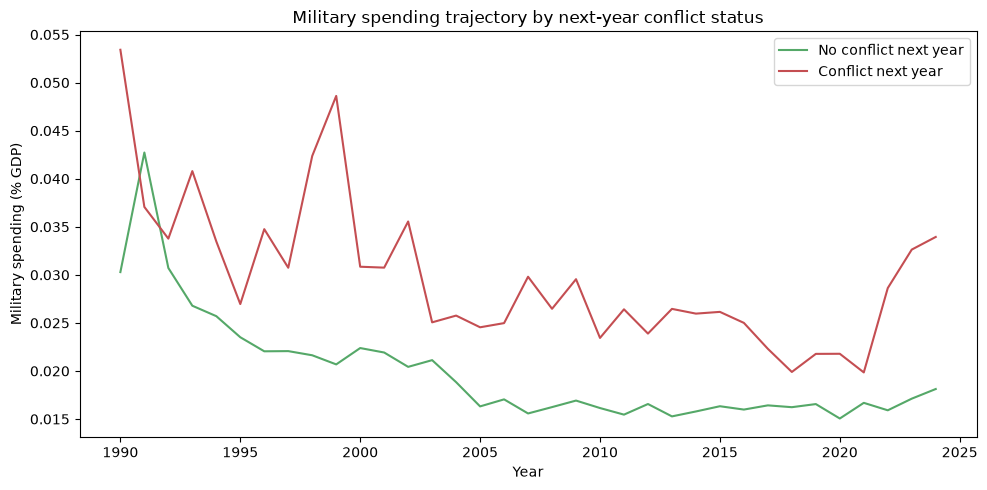

In [116]:
spend_trend = merged.groupby(["Year", "conflict_active_next_year"])["milex_pct_gdp"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
spend_trend[0.0].plot(ax=ax, label="No conflict next year", color="#55A868")
spend_trend[1.0].plot(ax=ax, label="Conflict next year", color="#C44E52")
ax.set_ylabel("Military spending (% GDP)")
ax.legend()
ax.set_title("Military spending trajectory by next-year conflict status")
plt.tight_layout()
plt.show()

A summary view of how all four variables (trust, threat, spending, speech length) relate to one another.

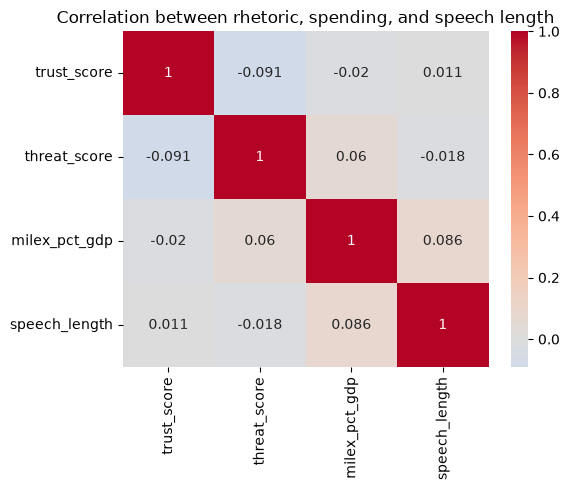

In [120]:
import seaborn as sns

corr_vars = merged[["trust_score", "threat_score", "milex_pct_gdp", "speech_length"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_vars, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation between rhetoric, spending, and speech length")
plt.tight_layout()
plt.show()

**Summary of exploratory findings.** All three signals — trust rhetoric (p = 0.0014, d = -0.112), threat rhetoric (p = 0.0065, d = 0.096), and military spending (p < 0.0001, d = 0.361) — differ significantly between countries that do and do not experience conflict the following year, each in the theoretically expected direction. However, effect sizes reveal military spending as the substantively dominant signal; the rhetorical differences, while statistically real, are small in practical magnitude. This finding directly motivates our predictive question: whether combining these signals, with spending as the primary driver, can meaningfully forecast next-year conflict risk.